In [9]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB

In [10]:
# 3-node market example from the formulation section (with N-1 security checks).
# Note: The narrative uses Gen 1 at 3 MW in the congestion logic, so pmax is set to 3.0 here.

nodes = ["A", "B", "C"]
node_to_idx = {node: i for i, node in enumerate(nodes)}

# Supply offers
generators = pd.DataFrame(
    [
        {"gen": "Gen 1", "node": "A", "offer": 5.0, "pmax": 3.0},
        {"gen": "Gen 2", "node": "B", "offer": 10.0, "pmax": 10.0},
        {"gen": "Gen 3", "node": "C", "offer": 7.5, "pmax": 0.5},
    ]
)

# Demand bids (served load is a decision variable up to demand)
loads = pd.DataFrame(
    [
        {"load": "Load 1", "node": "A", "demand": 1.0, "bid": 6.5},
        {"load": "Load 2", "node": "C", "demand": 2.0, "bid": 7.5},
        {"load": "Load 3", "node": "C", "demand": 1.5, "bid": 10.0},
    ]
)

# Branch data from the 3-node example diagrams
# x is line reactance used to derive PTDFs (chosen so A->C transfer resembles the narrative split)
lines = pd.DataFrame(
    [
        {"line": "A-B", "from": "A", "to": "B", "limit": 2.0, "x": 9.0},
        {"line": "B-C", "from": "B", "to": "C", "limit": 10.0, "x": 9.0},
        {"line": "A-C", "from": "A", "to": "C", "limit": 2.0, "x": 1.0},
    ]
)


def build_ptdf(active_lines_df, slack="C"):
    """Return PTDF matrix (line x node) for active lines under a fixed slack bus."""
    n = len(nodes)
    m = active_lines_df.shape[0]

    Bbus = np.zeros((n, n), dtype=float)
    Bf = np.zeros((m, n), dtype=float)

    for r, (frm, to, x) in enumerate(active_lines_df[["from", "to", "x"]].itertuples(index=False, name=None)):
        i = node_to_idx[frm]
        j = node_to_idx[to]
        b = 1.0 / float(x)

        Bbus[i, i] += b
        Bbus[j, j] += b
        Bbus[i, j] -= b
        Bbus[j, i] -= b

        # Flow is oriented from "from" to "to"
        Bf[r, i] = b
        Bf[r, j] = -b

    slack_idx = node_to_idx[slack]
    keep = [i for i in range(n) if i != slack_idx]

    Bred = Bbus[np.ix_(keep, keep)]
    Bred_inv = np.linalg.inv(Bred)

    ptdf = np.zeros((m, n), dtype=float)

    for node, idx in node_to_idx.items():
        inj = np.zeros(n, dtype=float)
        inj[idx] = 1.0
        inj[slack_idx] -= 1.0

        theta_red = Bred_inv @ inj[keep]
        theta = np.zeros(n, dtype=float)
        theta[keep] = theta_red

        ptdf[:, idx] = Bf @ theta

    return ptdf


# Base case + all single-line outage scenarios
scenarios = {
    "base": lines.copy().reset_index(drop=True),
    "A-B_down": lines[lines["line"] != "A-B"].copy().reset_index(drop=True),
    "B-C_down": lines[lines["line"] != "B-C"].copy().reset_index(drop=True),
    "A-C_down": lines[lines["line"] != "A-C"].copy().reset_index(drop=True),
}

N = len(nodes)
G = generators.shape[0]
D = loads.shape[0]

# Map dispatch variables to node injections: inj = injection_map @ [g, d]
gen_node_map = np.zeros((N, G), dtype=float)
for j, node in enumerate(generators["node"]):
    gen_node_map[node_to_idx[node], j] = 1.0

load_node_map = np.zeros((N, D), dtype=float)
for j, node in enumerate(loads["node"]):
    load_node_map[node_to_idx[node], j] = -1.0

injection_map = np.hstack((gen_node_map, load_node_map))

model = gp.Model("three_node_congestion")
model.Params.OutputFlag = 0

p_gen = model.addMVar(G, lb=0.0, ub=generators["pmax"].to_numpy(), name="p_gen")
p_load = model.addMVar(D, lb=0.0, ub=loads["demand"].to_numpy(), name="p_load")

x_dispatch = gp.hstack((p_gen, p_load))

# Maximize total bid value minus generation offer costs (social surplus)
obj_c = np.hstack((-generators["offer"].to_numpy(), loads["bid"].to_numpy()))
model.setMObjective(Q=None, c=obj_c, constant=0.0, sense=GRB.MAXIMIZE)

# System power balance
balance_row = np.hstack((np.ones(G), -np.ones(D))).reshape(1, G + D)
model.addMConstr(balance_row, x_dispatch, "=", np.array([0.0]), name="power_balance")

scenario_cache = {}
for scenario_name, active_lines in scenarios.items():
    ptdf = build_ptdf(active_lines, slack="C")
    flow_map = ptdf @ injection_map
    limits = active_lines["limit"].to_numpy(dtype=float)

    model.addMConstr(flow_map, x_dispatch, "<=", limits, name=f"{scenario_name}_flow_max")
    model.addMConstr(flow_map, x_dispatch, ">=", -limits, name=f"{scenario_name}_flow_min")

    scenario_cache[scenario_name] = {
        "lines": active_lines,
        "ptdf": ptdf,
        "limits": limits,
    }

model.optimize()

if model.Status != GRB.OPTIMAL:
    raise RuntimeError(f"Optimization ended with status {model.Status}")

print(f"Optimal social surplus: {model.ObjVal:.4f}\n")

gen_results = generators.copy()
gen_results["dispatch_mw"] = np.round(p_gen.X, 4)
print("Generation dispatch (MW):")
print(gen_results[["gen", "node", "offer", "pmax", "dispatch_mw"]], "\n")

load_results = loads.copy()
load_results["served_mw"] = np.round(p_load.X, 4)
load_results["fraction_served"] = np.round(load_results["served_mw"] / load_results["demand"], 4)
print("Load served (MW):")
print(load_results[["load", "node", "bid", "demand", "served_mw", "fraction_served"]], "\n")

injections = injection_map @ np.hstack((p_gen.X, p_load.X))
print("Nodal net injections (MW):")
print(pd.Series(np.round(injections, 4), index=nodes), "\n")

all_binding_lines = []
for scenario_name, cache in scenario_cache.items():
    line_flows = cache["ptdf"] @ injections
    limits = cache["limits"]
    binding = np.isclose(np.abs(line_flows), limits, atol=1e-6)

    flow_df = pd.DataFrame(
        {
            "line": cache["lines"]["line"].to_numpy(),
            "flow_mw": np.round(line_flows, 4),
            "limit_mw": limits,
            "utilization": np.round(np.abs(line_flows) / limits, 4),
            "binding": binding,
        }
    )

    print(f"Scenario: {scenario_name}")
    print(flow_df, "\n")

    for line_name in flow_df.loc[flow_df["binding"], "line"]:
        all_binding_lines.append((scenario_name, line_name))

if all_binding_lines:
    print("Congestion detected (binding transmission constraints):")
    for scenario_name, line_name in all_binding_lines:
        print(f"- {scenario_name}: {line_name}")
else:
    print("No congestion detected (no binding transmission constraints).")

Optimal social surplus: 10.2500

Generation dispatch (MW):
     gen node  offer  pmax  dispatch_mw
0  Gen 1    A    5.0   3.0          3.0
1  Gen 2    B   10.0  10.0          0.0
2  Gen 3    C    7.5   0.5          0.0 

Load served (MW):
     load node   bid  demand  served_mw  fraction_served
0  Load 1    A   6.5     1.0        1.0             1.00
1  Load 2    C   7.5     2.0        0.5             0.25
2  Load 3    C  10.0     1.5        1.5             1.00 

Nodal net injections (MW):
A    2.0
B    0.0
C   -2.0
dtype: float64 

Scenario: base
  line  flow_mw  limit_mw  utilization  binding
0  A-B   0.1053       2.0       0.0526    False
1  B-C   0.1053      10.0       0.0105    False
2  A-C   1.8947       2.0       0.9474    False 

Scenario: A-B_down
  line  flow_mw  limit_mw  utilization  binding
0  B-C      0.0      10.0          0.0    False
1  A-C      2.0       2.0          1.0     True 

Scenario: B-C_down
  line  flow_mw  limit_mw  utilization  binding
0  A-B      0.0    

Final nodal injection summary (MW):
  node  net_injection_mw
0    A               2.0
1    B               0.0
2    C              -2.0 

Tight (binding) transmission constraints:
scenario line  flow_mw  limit_mw
A-B_down  A-C      2.0       2.0
B-C_down  A-C      2.0       2.0
A-C_down  A-B      2.0       2.0


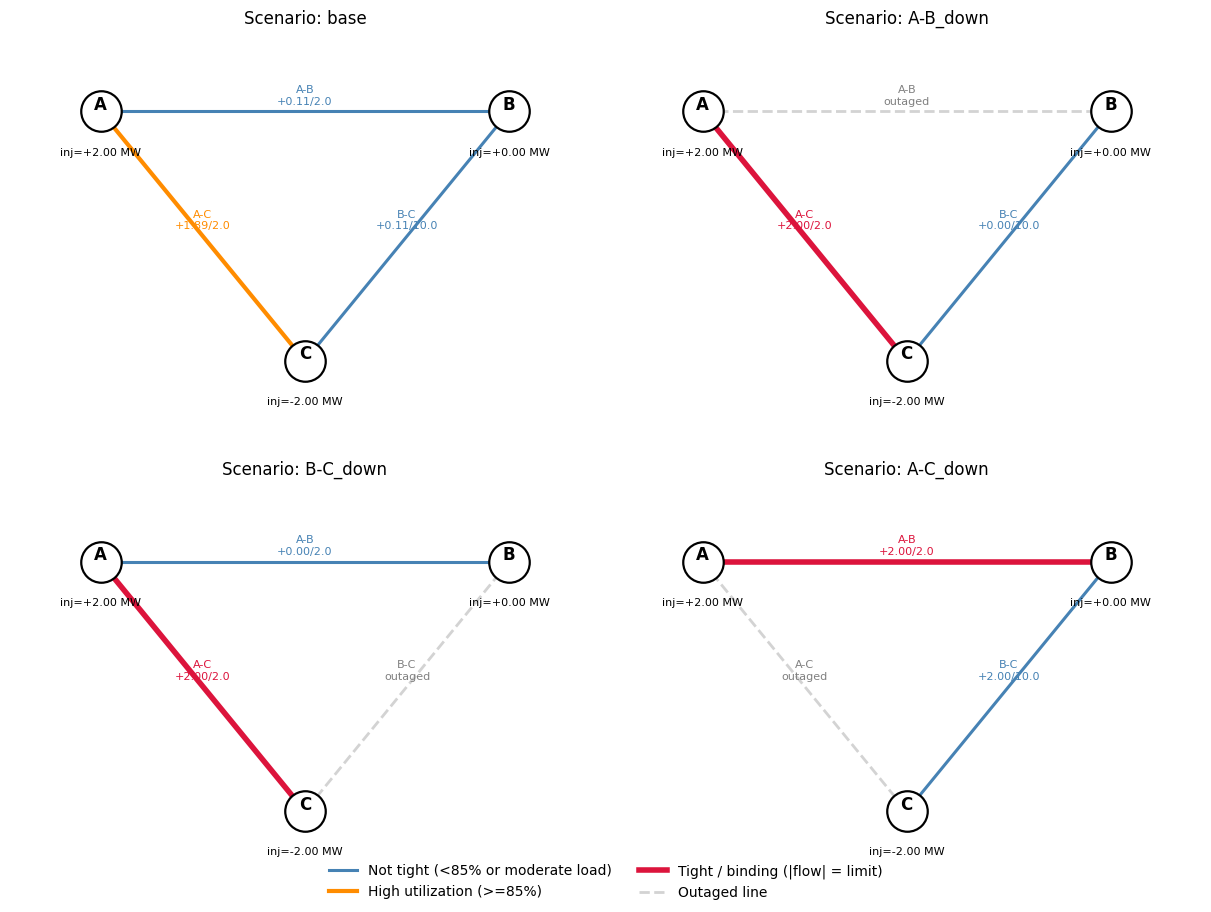

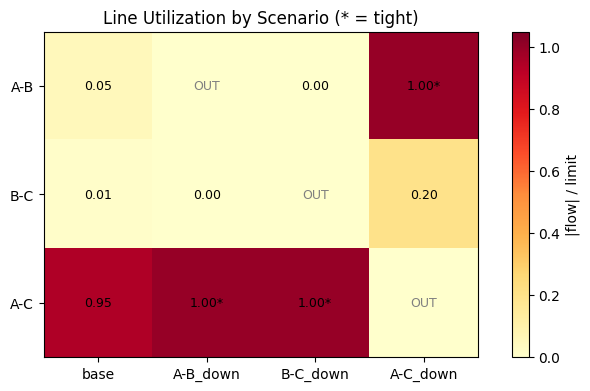

In [12]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Summarize final dispatch and identify tight constraints across all scenarios.
summary_dispatch = pd.DataFrame(
    {
        "node": nodes,
        "net_injection_mw": np.round(injections, 4),
    }
)

print("Final nodal injection summary (MW):")
print(summary_dispatch, "\n")

scenario_order = ["base", "A-B_down", "B-C_down", "A-C_down"]
line_order = lines["line"].tolist()

records = []
for scenario_name in scenario_order:
    cache = scenario_cache[scenario_name]
    flow_vals = cache["ptdf"] @ injections

    for line_name, flow_mw, limit_mw in zip(
        cache["lines"]["line"].to_numpy(),
        flow_vals,
        cache["limits"],
    ):
        util = abs(flow_mw) / limit_mw
        tight = np.isclose(abs(flow_mw), limit_mw, atol=1e-6)
        records.append(
            {
                "scenario": scenario_name,
                "line": line_name,
                "flow_mw": flow_mw,
                "limit_mw": limit_mw,
                "utilization": util,
                "tight": tight,
            }
        )

line_stats = pd.DataFrame(records)

print("Tight (binding) transmission constraints:")
tight_df = line_stats.loc[line_stats["tight"], ["scenario", "line", "flow_mw", "limit_mw"]].copy()
if tight_df.empty:
    print("None")
else:
    tight_df["flow_mw"] = tight_df["flow_mw"].round(4)
    print(tight_df.to_string(index=False))

# Build matrices for a compact utilization heatmap.
util_matrix = pd.DataFrame(np.nan, index=line_order, columns=scenario_order)
for _, row in line_stats.iterrows():
    util_matrix.loc[row["line"], row["scenario"]] = row["utilization"]

# Graphical network view for each scenario.
node_xy = {
    "A": (0.0, 1.0),
    "B": (1.8, 1.0),
    "C": (0.9, -0.1),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
all_edges = lines[["line", "from", "to", "limit"]].copy()

for ax, scenario_name in zip(axes.flat, scenario_order):
    cache = scenario_cache[scenario_name]
    active_lines = cache["lines"].copy()
    active_flows = cache["ptdf"] @ injections

    flow_by_line = dict(zip(active_lines["line"], active_flows))
    limit_by_line = dict(zip(active_lines["line"], active_lines["limit"]))

    ax.set_title(f"Scenario: {scenario_name}")

    for _, edge in all_edges.iterrows():
        line_name = edge["line"]
        n1 = edge["from"]
        n2 = edge["to"]

        x1, y1 = node_xy[n1]
        x2, y2 = node_xy[n2]
        xm, ym = (x1 + x2) / 2.0, (y1 + y2) / 2.0

        if line_name in flow_by_line:
            flow_mw = flow_by_line[line_name]
            limit_mw = limit_by_line[line_name]
            util = abs(flow_mw) / limit_mw
            is_tight = np.isclose(abs(flow_mw), limit_mw, atol=1e-6)

            if is_tight:
                color = "crimson"
                lw = 4.0
            elif util >= 0.85:
                color = "darkorange"
                lw = 3.0
            else:
                color = "steelblue"
                lw = 2.2

            ax.plot([x1, x2], [y1, y2], color=color, linewidth=lw, zorder=1)
            ax.text(
                xm,
                ym + 0.07,
                f"{line_name}\n{flow_mw:+.2f}/{limit_mw:.1f}",
                ha="center",
                va="center",
                fontsize=8,
                color=color,
            )
        else:
            ax.plot([x1, x2], [y1, y2], color="lightgray", linewidth=2.0, linestyle="--", zorder=1)
            ax.text(
                xm,
                ym + 0.07,
                f"{line_name}\noutaged",
                ha="center",
                va="center",
                fontsize=8,
                color="gray",
            )

    for node in nodes:
        x, y = node_xy[node]
        inj = injections[node_to_idx[node]]
        ax.scatter([x], [y], s=850, c="white", edgecolors="black", linewidths=1.6, zorder=2)
        ax.text(x, y + 0.03, node, ha="center", va="center", fontsize=12, weight="bold")
        ax.text(x, y - 0.18, f"inj={inj:+.2f} MW", ha="center", va="center", fontsize=8)

    ax.set_xlim(-0.4, 2.2)
    ax.set_ylim(-0.5, 1.35)
    ax.set_aspect("equal")
    ax.axis("off")

legend_items = [
    Line2D([0], [0], color="steelblue", lw=2.2, label="Not tight (<85% or moderate load)"),
    Line2D([0], [0], color="darkorange", lw=3.0, label="High utilization (>=85%)"),
    Line2D([0], [0], color="crimson", lw=4.0, label="Tight / binding (|flow| = limit)"),
    Line2D([0], [0], color="lightgray", lw=2.0, linestyle="--", label="Outaged line"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=2, frameon=False)
plt.show()

# Heatmap of |flow|/limit across scenarios.
heat_values = util_matrix.to_numpy(dtype=float)
heat_for_plot = np.nan_to_num(heat_values, nan=0.0)

fig2, ax2 = plt.subplots(figsize=(8, 3.8), constrained_layout=True)
im = ax2.imshow(heat_for_plot, cmap="YlOrRd", vmin=0.0, vmax=1.05)

for i, line_name in enumerate(line_order):
    for j, scenario_name in enumerate(scenario_order):
        val = util_matrix.loc[line_name, scenario_name]
        if pd.isna(val):
            label = "OUT"
            color = "gray"
        else:
            is_tight = np.isclose(val, 1.0, atol=1e-6)
            label = f"{val:.2f}" + ("*" if is_tight else "")
            color = "black"
        ax2.text(j, i, label, ha="center", va="center", fontsize=9, color=color)

ax2.set_xticks(np.arange(len(scenario_order)))
ax2.set_xticklabels(scenario_order)
ax2.set_yticks(np.arange(len(line_order)))
ax2.set_yticklabels(line_order)
ax2.set_title("Line Utilization by Scenario (* = tight)")

cbar = fig2.colorbar(im, ax=ax2)
cbar.set_label("|flow| / limit")
plt.show()